In [29]:
#Making graph
def prepareEdge(edge, source, destination):# 定义一个函数，用于处理边的数据，此函数目的是将重复的边以权重的形式保存
    if (len(edge) == 0):# 如果边的列表为空，添加一条新的边，包括起始节点、目标节点和权重
        edge.append((source, destination, 1));
    insertIndex = -1;# 初始化插入索引为-1，用于检查边是否已经存在
    for i in range(0, len(edge)):  # 遍历已有的边
        if (edge[i][0] == source and edge[i][1] == destination):  # 如果找到已存在的边（起始节点和目标节点相同）
            insertIndex = i;
    if (insertIndex != -1): # 如果边已经存在，更新它的权重
        edge[insertIndex]=(edge[insertIndex][0], edge[insertIndex][1], edge[insertIndex][2]+1)
    else:# 如果边不存在，添加一条新的边
        edge.append((source, destination, 1))
    return edge


count = 1
file = open('../Dataset/Car_Hacking_Challenge_Dataset_rev20Mar2021/Pre_submit_D.csv', 'r')
f= open('../Graph and Features/MixedAttackGraph.txt',"w+")

msgIDs = {};# 初始化一个字典，用于计算每个id的出现次数
edge = []
prev = ''# 用于存储前一行的目标节点
s = '';# 用于构建文件的内容
attacked = 0;# 用于标记最后受到攻击的是数据集中第几条消息
category = '' #category对应图中最后一个受到攻击的消息受到的攻击类型

# 跳过第一行,因为是timestamp id dlc data class等
next(file)
for line in file:
# for i in range(1,92001):
#     line = file.readline()

    if (count%200 == 1):# 如果计数器除以200的余数为1，表示新的一组数据开始
        
        Xpartition = line.split(',');
#         print(Xpartition)
        prev = Xpartition[1]#得到每组的第一个ID
    
        first_timestamp = Xpartition[0]# 用于记录每组数据的第一条消息的时间戳


    Xpartition = line.split(',');#得到当前行的数据
#     print(Xpartition)
    if (Xpartition[1] in msgIDs.keys()):# 如果ID在字典中，出现次数加一
        msgIDs[Xpartition[1]] += 1;
    else:
        msgIDs[Xpartition[1]] = 1#不在字典中，初始化其出现次数为1
    if (prev != '' and count != 1):

        if(prev != Xpartition[1]):#防止每次生成图第一个结点指向自己
         edge =prepareEdge(edge, prev, Xpartition[1])#得到的图不包括重复节点 比如0545 -->  02b0 05f0

         prev = Xpartition[1] # 更新 prev 为当前消息的内容

    if (Xpartition[len(Xpartition)-2] == 'Attack'):#数据集中倒数第二列为Attack或者Normal
        attacked = count;#记录收到攻击的消息是第几个消息

        category = Xpartition[len(Xpartition)-1].strip()#注意这里自动带换行符，即Flooding\n,使用strip()方法移除换行符

        
    if (count%200 == 0): # 如果计数器除以200的余数为0，表示已处理完一组数据
        last_timestamp = Xpartition[0]# 用于记录每组数据的最后一条消息的时间戳
        #求得时间差
        time_difference = float(last_timestamp) - float(first_timestamp)

        s+= 'Graph No: ' + str(int(count/200)) + ':\n';# 构建输出内容，包括图的编号

        #如果最后一个收到攻击的消息在count-200 和count的范围内，则证明此200消息中有收到攻击的消息，即被攻击了
        if (count -200 < attacked and attacked <= count ): 
            s+= 'Attack Free: ' 'False ' + str(attacked) + ' Time Difference: ' + str(time_difference) + ' Class: ' + category + '\n';#str(attacked)为这200条消息中最后一个受到攻击的消息的号
        else:
            s+= 'Attack Free: ' 'True ' + str(attacked) + ' Time Difference: ' + str(time_difference) + ' Class: ' + 'Normal' + '\n';#未受到攻击的可以将这里的str(attacked)改为0
        for key in msgIDs:
            s+= str(key) + ' --> ';
            for i in range(0, len(edge)):
                if(key == edge[i][0]):
                    s+= edge[i][1] + ' '
            s+= '\n'
        msgIDs = {};
        edge = [];
    count +=1 

f.write(s)
f.close()

In [30]:
## 导入必要的库
import networkx as nx  # 用于处理网络图的库
import hashlib  # 用于生成哈希值的库
import numpy as np  # 用于数值计算的库

# 创建两个有向图，用于表示被攻击的网络和未被攻击的网络
gAttacked = nx.DiGraph()
gAttackfree = nx.DiGraph()

# 定义一个函数，用于获取攻击和未攻击的图的信息
def getAttackFreelist(filename):
    # 创建一个空列表，用于存储图的信息
    attacFreekList = []
    # 打开指定文件
    file_ = open(filename, 'r')

    # 初始化计数器，用于追踪图的数量
    graphCounter = 0
    while True:
        # 逐行读取文件
        line = file_.readline()
        # 如果已经到达文件末尾，退出循环
        if not line:
            break

        # 从行中提取前5个字符，通常是"Graph"，用于标识新的图开始
        graph_number = line[0:5]

        if graph_number == "Graph":
            # 增加图计数器
            graphCounter += 1
            # 读取下一行，通常包含图的信息，将其分割为列表并添加到attacFreekList中
            line = file_.readline()
            attacFreekList.append(line.split())

    # 关闭文件
    file_.close()

    # 打印信息，包括图的数量和每个图的信息
    print(len(attacFreekList))
    print(attacFreekList)
    # 返回包含图信息的列表
    return attacFreekList

# 定义一个函数，用于提取图的特征
def getFeatures(filename):
    # 调用getAttackFreelist函数获取攻击和未攻击图的信息，并存储在attackFreeList中
    attackFreeList = getAttackFreelist(filename)
    # 打开文件以读取数据
    file_ = open(filename, 'r')

    # 初始化用于存储图的列表
    graphList = []
    ultimate_graphList = []
    # 初始化图计数器
    graphCounter = 0
    while True:
        # 逐行读取文件
        line = file_.readline()
        # 如果已经到达文件末尾，退出循环
        if not line:
            break

        # 从行中提取前5个字符，通常是"Graph"，用于标识新的图开始
        graph_number = line[0:5]

        if graph_number == "Graph":
            # 增加图计数器
            graphCounter += 1
            # 读取下两行，通常包含图的信息，将其分割为列表并添加到ultimate_graphList中
            line = file_.readline()
            line = file_.readline()

            # 如果图计数器大于等于2，表示已经读取完前一个图的信息，将其添加到ultimate_graphList中
            if graphCounter >= 2:
                ultimate_graphList.append(graphList)
                graphList = []

        # 将每行数据以空格分割成列表，然后将列表添加到graphList中
        list1 = line.split()
        graphList.append(list1)

    # 将最后一个图的信息添加到ultimate_graphList中
    ultimate_graphList.append(graphList)
#     print(ultimate_graphList[0])
    # 关闭文件
    file_.close()
#     print(ultimate_graphList[0][1])#['02b0', '-->', '0002', '0430']
#     print(graphCounter)

    # 初始化用于存储所有特征的列表
    list_All_Feature_Set = []
    
    # 生成一个文件名，用于将特征写入新文件
    filetowrite = filename[:-4] + "_GraphFeatures.txt"
    # 打开一个新文件以写入特征
    file1 = open(filetowrite, 'w')

    # 获取图的总数
    graphNumber = len(ultimate_graphList)
#     print(graphNumber) 2831


    # 迭代每个图
    for i in range(0, graphNumber):
        # 创建一个有向图对象
        G = nx.DiGraph()
        
        # 获取当前图顶点数
        graphVertexNumber = len(ultimate_graphList[i])

        # 遍历每个顶点
        for j in range(0, graphVertexNumber):
            # 当前边的长度，['02b0', '-->', '0002', '0430']长度为4
            vertexConnectionLength = len(ultimate_graphList[i][j])
#             print(vertexConnectionLength)
#             break
            # 遍历连接，将节点和它们的关系添加到图G中
            for k in range(2, vertexConnectionLength):#因为0 1对应的不是边 2开始才是边
                if(ultimate_graphList[i][j][0] == ultimate_graphList[i][j][k]):############
                    continue
                G.add_edge(ultimate_graphList[i][j][0], ultimate_graphList[i][j][k])

        # 获取图的边数和节点数
        edge = G.number_of_edges()
        node = G.number_of_nodes()

        # 计算介数中心性
        betweenness_centrality = nx.betweenness_centrality(G)
#         # 计算特征向量中心性
#         eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=500, tol=1e-4)
        # 获取介数中心性和向量中心性的值
        betweenness_values = list(betweenness_centrality.values())
#         eigenvector_values = list(eigenvector_centrality.values())

        # 计算介数中心性和向量中心性的中值
        max_betweenness = np.max(betweenness_values)
#         max_eigenvector = np.max(eigenvector_values)

        #图的密度
        density = nx.density(G)
#         #强联通分量
#         strongly_connected_components = list(nx.strongly_connected_components(G))
#         num_strongly_connected_components = len(strongly_connected_components)


        # 如果i等于0，表示第一个图之前将特征的标题写入文件
        if i == 0:
            file1.write("No." + "\t" + "Nodes\t" + "Edges\t" + "MaximumIndegree\t"  + "MinimumIndegree\t" +
                        "MaximumOutdegree\t"  + "MinimumOutdegree\t"  + "Time Difference\t" +
                        "max_betweenness_centrality\t" + "density\t" + "State\t" +
                        "Class\n")

        # 写入特征信息到文件
        file1.write(str(i + 1) + "\t")
        counter = 0
        in_deg = []
        out_deg = []
        for j in range(0, graphVertexNumber):
            in_deg.append(G.in_degree(ultimate_graphList[i][j][0]))
            out_deg.append(G.out_degree(ultimate_graphList[i][j][0]))
        
        maxInd = np.max(in_deg)
        minInd = np.min(in_deg)
        maxOut = np.max(out_deg)
        minOut = np.min(out_deg)
        file1.write(str(node) + "\t") 
        file1.write(str(edge) + "\t")
        file1.write(str(maxInd) + str("\t") + str(minInd)+ str("\t"))
        file1.write(str(maxOut) + str("\t") + str(minOut)+ str("\t"))       
        file1.write(str(attackFreeList[i][6]) + str("\t"))
        file1.write(str(max_betweenness) + str("\t") +
                    str(density) + str("\t")  +
                    str(attackFreeList[i][2]) + str("\t") + str(attackFreeList[i][8]) + "\n")


    # 关闭文件
    file1.close()

# 调用getFeatures函数来处理指定的文件
getFeatures('../Graph and Features/MixedAttackGraph.txt')


10003
[['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.08214330673217773', 'Class:', 'Normal'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.08507704734802246', 'Class:', 'Normal'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.08016800880432129', 'Class:', 'Normal'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.0823678970336914', 'Class:', 'Normal'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.08072090148925781', 'Class:', 'Normal'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.08473515510559082', 'Class:', 'Normal'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.08161497116088867', 'Class:', 'Normal'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.0846409797668457', 'Class:', 'Normal'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.08455109596252441', 'Class:', 'Normal'], ['Attack', 'Free:', 'True', '0', 'Time', 'Difference:', '0.0794527530670166', 'Class:', 'Normal

In [79]:
#GNB
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd

dataframe = pd.read_table('../Graph and Features/MixedAttackGraph_GraphFeatures.txt')
dataset = dataframe.values

# 分割特征和标签
X = dataset[:, 1:10]  # 选择特征列
State = dataset[:, -2]  # State列

y = []
# 根据 State 判断类别
for i in range(len(dataset)):
    if State[i] == True:
        y.append(0)  # 类别为 normal
    else:
        attack_type = dataset[i, -1]
        if attack_type == 'Spoofing':
            y.append(1)
        elif attack_type == 'Fuzzing':
            y.append(2)
        elif attack_type == 'Flooding':
            y.append(3)
        elif attack_type == 'Replay':
            y.append(4)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.32, random_state=42)

# 创建高斯朴素贝叶斯分类器
gnb = GaussianNB()

# 训练模型
gnb.fit(X_train, y_train)

# 预测
y_pred = gnb.predict(X_test)

# 计算每个攻击类型的准确率
accuracy_spoofing = accuracy_score([1 if label == 1 else -1 for label in y_test], [1 if pred == 1 else -1 for pred in y_pred])
accuracy_fuzzing = accuracy_score([2 if label == 2 else -1 for label in y_test], [2 if pred == 2 else -1 for pred in y_pred])
accuracy_flooding = accuracy_score([3 if label == 3 else -1 for label in y_test], [3 if pred == 3 else -1 for pred in y_pred])
accuracy_replay = accuracy_score([4 if label == 4 else -1 for label in y_test], [4 if pred == 4 else -1 for pred in y_pred])

print(f"Spoofing 准确率: {accuracy_spoofing:.10f}")
print(f"Fuzzing 准确率: {accuracy_fuzzing:.10f}")
print(f"Flooding 准确率: {accuracy_flooding:.10f}")
print(f"Replay 准确率: {accuracy_replay:.10f}")

overall_accuracy = accuracy_score(y_test, y_pred)
print(f"整体准确率: {overall_accuracy:.10f}")


Spoofing 准确率: 0.9978131834
Fuzzing 准确率: 0.9887535145
Flooding 准确率: 0.9996875976
Replay 准确率: 0.9875039050
整体准确率: 0.9850046860


In [9]:
### DecisionTree
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
dataframe = pd.read_table('../Graph and Features/MixedAttackGraph_GraphFeatures.txt')
dataset = dataframe.values
# print(dataset)
# 分割特征和标签
X = dataset[:, 1:10]  # 选择特征列
State = dataset[:, -2]  # State列

# print(len(dataset))
# break
y = []
x=[]
# 根据 State 判断类别
for i in range(len(dataset)):
#     print(State[i])
    if State[i] == True:
        y.append(0)  # 类别为 normal
        
    else:
        # 进一步判断攻击类型
        attack_type = dataset[i, -1]
        if attack_type == 'Spoofing':
            y.append(1)
        elif attack_type == 'Fuzzing':
            y.append(2)
        elif attack_type == 'Flooding':
            y.append(3)
        elif attack_type == 'Replay':
            y.append(4)
   
# print(len(y))

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建决策树分类器
clf = DecisionTreeClassifier(random_state=42, max_depth = 7)

# 训练模型
clf.fit(X_train, y_train)

# 预测
y_pred = clf.predict(X_test)

# 计算每个攻击类型的准确率
accuracy_normal = accuracy_score([0 if label == 0 else -1 for label in y_test], [0 if pred == 0 else -1 for pred in y_pred])
accuracy_spoofing = accuracy_score([1 if label == 1 else -1 for label in y_test], [1 if pred == 1 else -1 for pred in y_pred])
accuracy_fuzzing = accuracy_score([2 if label == 2 else -1 for label in y_test], [2 if pred == 2 else -1 for pred in y_pred])
accuracy_flooding = accuracy_score([3 if label == 3 else -1 for label in y_test], [3 if pred == 3 else -1 for pred in y_pred])
accuracy_replay = accuracy_score([4 if label == 4 else -1 for label in y_test], [4 if pred == 4 else -1 for pred in y_pred])
# target_names = [ "Normal", "Spoofing", "Fuzzing", "Flooding", "Replay"]

# print('classification report')

# print(classification_report(y_test, y_pred, target_names=target_names))

print(f"Normal 准确率: {accuracy_normal:.6f}")
print(f"Spoofing 准确率: {accuracy_spoofing:.6f}")
print(f"Fuzzing 准确率: {accuracy_fuzzing:.6f}")
print(f"Flooding 准确率: {accuracy_flooding:.6f}")
print(f"Replay 准确率: {accuracy_replay:.6f}")
# 计算整体评估指标  
overall_accuracy = accuracy_score(y_test, y_pred)
overall_precision = precision_score(y_test, y_pred, average='weighted')  
overall_recall = recall_score(y_test, y_pred, average='weighted')  
overall_f1 = f1_score(y_test, y_pred, average='weighted')  

print(f"整体准确率: {overall_accuracy:.6f}")
print(f"整体 Precision: {overall_precision:.6f}")  
print(f"整体 Recall: {overall_recall:.6f}")  
print(f"整体 F1: {overall_f1:.6f}")  
conf_matrix = confusion_matrix(y_test, y_pred)
# 打印混淆矩阵
print("混淆矩阵:")
print(conf_matrix)
# 计算评估指标
accuracy = [accuracy_normal, accuracy_spoofing, accuracy_fuzzing, accuracy_flooding, accuracy_replay]
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
# print(accuracy)
# 将评估指标放入DataFrame中
df = pd.DataFrame({'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1}, index=['Normal', 'Spoofing', 'Fuzzing', 'Flooding', 'Replay'])
df.index.name = 'Attack Type'

# 打印表格
print(df)


Normal 准确率: 0.996668
Spoofing 准确率: 0.997001
Fuzzing 准确率: 0.994668
Flooding 准确率: 0.999667
Replay 准确率: 0.994668
整体准确率: 0.991336
整体 Precision: 0.991409
整体 Recall: 0.991336
整体 F1: 0.991345
混淆矩阵:
[[1449    2    3    0    1]
 [   4  472    0    0    2]
 [   0    0  262    0   10]
 [   0    1    0  414    0]
 [   0    0    3    0  378]]
             Accuracy  Precision    Recall        F1
Attack Type                                         
Normal       0.996668   0.997247  0.995876  0.996561
Spoofing     0.997001   0.993684  0.987448  0.990556
Fuzzing      0.994668   0.977612  0.963235  0.970370
Flooding     0.999667   1.000000  0.997590  0.998794
Replay       0.994668   0.966752  0.992126  0.979275


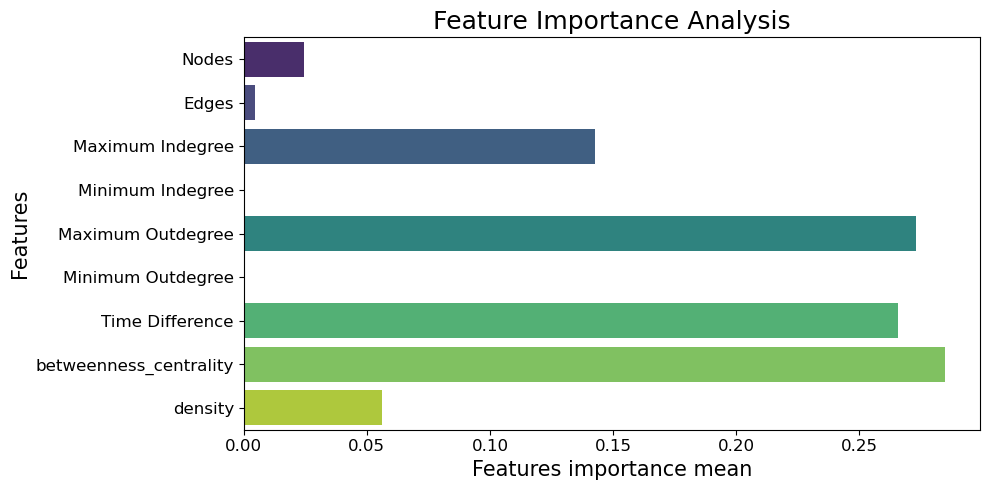

In [22]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

def plot_feature_importance(X, y):
    features = X[:, 1:10]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    imps = permutation_importance(clf, X_test, y_test)
    feature_names = ["Nodes", "Edges", "Maximum Indegree", "Minimum Indegree", "Maximum Outdegree",
                     "Minimum Outdegree", "Time Difference", "betweenness_centrality", "density"]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=imps.importances_mean, y=feature_names, palette='viridis')
    plt.xlabel('Features importance mean', fontsize=15)
    plt.ylabel('Features', fontsize=15)
    plt.title('Feature Importance Analysis', fontsize=18)
    plt.tick_params(labelsize=12)
    plt.tight_layout()
    plt.savefig('../PNG/mixed/Feature Importance Analysis_Car_Challenge.png', bbox_inches='tight')
    plt.show()

# 假设X和labels已被定义
plot_feature_importance(X, y)


混淆矩阵:
[[1449    2    3    0    1]
 [   4  472    0    0    2]
 [   0    0  262    0   10]
 [   0    1    0  414    0]
 [   0    0    3    0  378]]


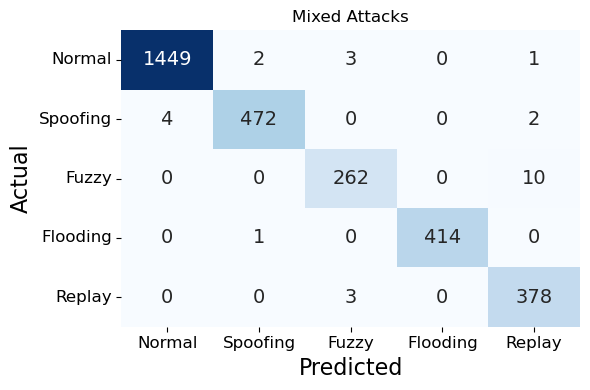

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 计算混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)

# 打印混淆矩阵
print("混淆矩阵:")
print(conf_matrix)

# 使用Seaborn绘制热力图展示混淆矩阵
plt.figure(figsize=(6, 4))
tick_labels = ['Normal', 'Spoofing', 'Fuzzy', 'Flooding', 'Replay']
hm = sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', annot_kws={"size": 14},
                 xticklabels=tick_labels, yticklabels=tick_labels, cbar=False)
plt.xlabel('Predicted', fontsize=16)
plt.ylabel('Actual', fontsize=16)
plt.title('Mixed Attacks')

hm.set_xticklabels(hm.get_xticklabels(), fontsize=12)
hm.set_yticklabels(hm.get_yticklabels(), fontsize=12, rotation=0)

plt.tight_layout()
plt.savefig('../PNG/mixed/confusion_matrix_Car_Challenge.png', dpi=600)
plt.show()


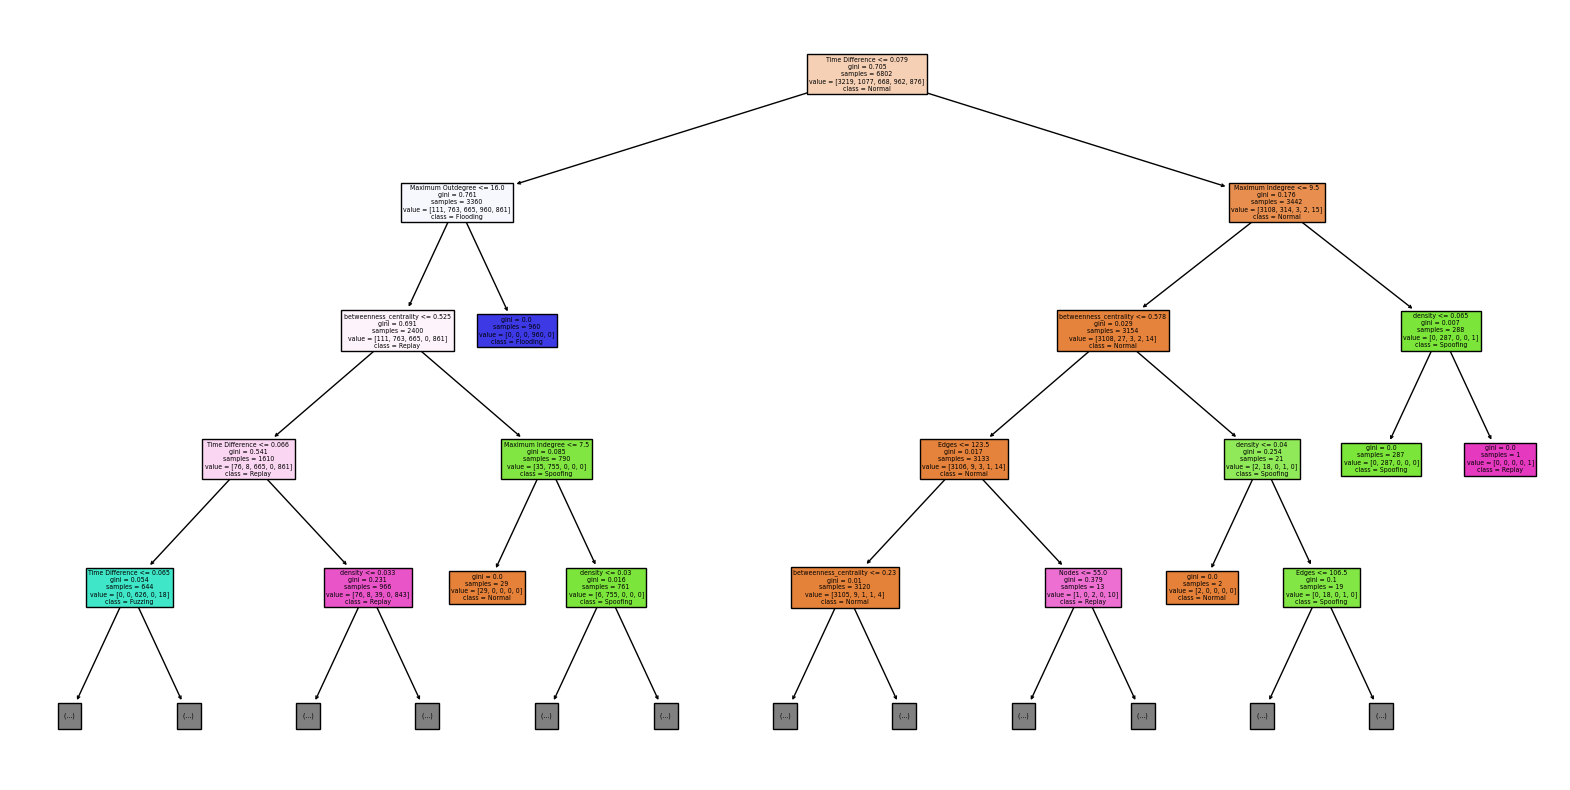

In [84]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 设置特征名称
feature_names = ["Nodes", "Edges", "Maximum Indegree", "Minimum Indegree", 
                 "Maximum Outdegree", "Minimum Outdegree", "Time Difference", 
                 "betweenness_centrality", "density"]

# 可视化决策树
plt.figure(figsize=(20, 10))
plot_tree(clf,  max_depth=4,feature_names=feature_names, class_names=["Normal", "Spoofing", "Fuzzing", "Flooding", "Replay"], filled=True)
plt.savefig('../PNG/mixed/DecisionTree_Car_defense_dataset.png',  bbox_inches='tight', dpi=100)
plt.show()

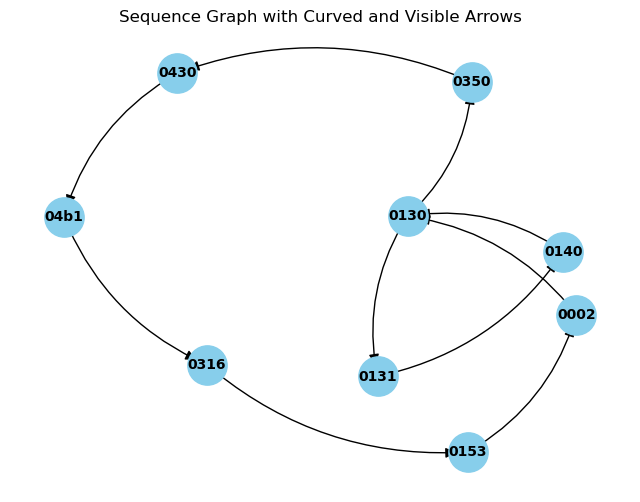

In [6]:
import networkx as nx  
import matplotlib.pyplot as plt  

# 定义ID序列  
id_sequence = ["0350", "0430", "04b1", "0316", "0153", "0002", "0130", "0131", "0140", "0130", "0350"]  

# 创建有向图  
G = nx.DiGraph()  

# 添加边  
for i in range(len(id_sequence)-1):  
    G.add_edge(id_sequence[i], id_sequence[i+1])  

# 创建绘图  
fig, ax = plt.subplots(figsize=(8, 6))  
pos = nx.spring_layout(G)  # 定义节点位置  

# 绘制曲线边，调整箭头大小和边宽度，避免被节点覆盖  
nx.draw_networkx_edges(  
    G,  
    pos,  
    edgelist=G.edges(),  
    connectionstyle="arc3,rad=0.2",  # 设置曲线  
    arrowsize=15,  # 调整箭头大小  
    width=1.0,  # 调整边的宽度  
    ax=ax  # 使用 Matplotlib 的 ax 对象  
)  

# 绘制节点  
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='skyblue', ax=ax)  

# 绘制标签  
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)  

# 添加标题  
plt.title("Sequence Graph with Curved and Visible Arrows")  
plt.axis("off")  
plt.show()